## Topic 3 : AI-Powered Movie Recommendation System

prompt :

🛠️ Tools You Will Use:
Python Essentials:Variables, conditionals, loops, and dictionaries.
Functions (custom, lambda, map, filter, reduce).
Object-oriented programming (OOP) concepts: inheritance, encapsulation, and polymorphism.
Data Analysis:Data preprocessing and transformation with Pandas and NumPy.
Statistical analysis and feature engineering.
Data Visualization: Using Matplotlib and Seaborn for exploratory data analysis and insights.
SciPy: Apply advanced statistical methods, hypothesis testing, and distribution fitting for more sophisticated analyses.
Generative AI Context: Simulating personalized content generation using basic recommendation logic and sequential patterns.


Topic 3 : AI-Powered Movie Recommendation System
Objective: 
Create a Python-based movie recommendation system that suggests 
movies based on user preferences and viewing history. This project 
mimics personalized Generative AI applications in the media and 
entertainment industry.
Workflow:

1. Simulate User Data: Create user profiles with:
Name, Age, and Preferred Genres (e.g., action, drama).
Viewing History: A log of movies watched, including genre, director, and rating.
Example:

{
    "name": "John",
    "age": 25,
    "preferences": ["action", "thriller"],
    "watch_history": [{"movie": "Inception", "genre": "sci-fi", "rating": 5}]
}


2. Build the Recommendation Engine:
Generate personalized recommendations by:

Filtering movies from a dataset that match the user’s preferences.
Ranking movies based on user ratings or genre overlap.
Simulate recommendations like: “Since you liked Inception, you might enjoy Interstellar.”

SciPy Application: Apply correlation metrics (e.g., Pearson 
correlation using scipy.stats.pearsonr) to compare the ratings given to 
movies by different users. This can help recommend movies based on 
similar user preferences or past ratings.
Additionally, use k-means clustering from scipy.cluster.vq to cluster
 users into groups based on their genre preferences or ratings, and then
 recommend the top-rated movies within each cluster.


3. Analyze and Visualize Insights:
Preferences: Plot the distribution of genres in a user’s watch history.
Trends: Visualize the change in user ratings over time.
Example Visualizations:

Pie chart of genres watched.
Line plot of user ratings over the past month.


--- Basic Recommendations for John ---
Since you like sci-fi, you might enjoy 'Interstellar'.

--- SciPy Pearson Correlation for User 1 ---
Similarity with User 3 (Mike): 0.07
Similarity with User 2 (Sarah): -0.68

--- SciPy K-Means Clustering ---
User 1 (John) belongs to Cluster 0
User 2 (Sarah) belongs to Cluster 1
User 3 (Mike) belongs to Cluster 0


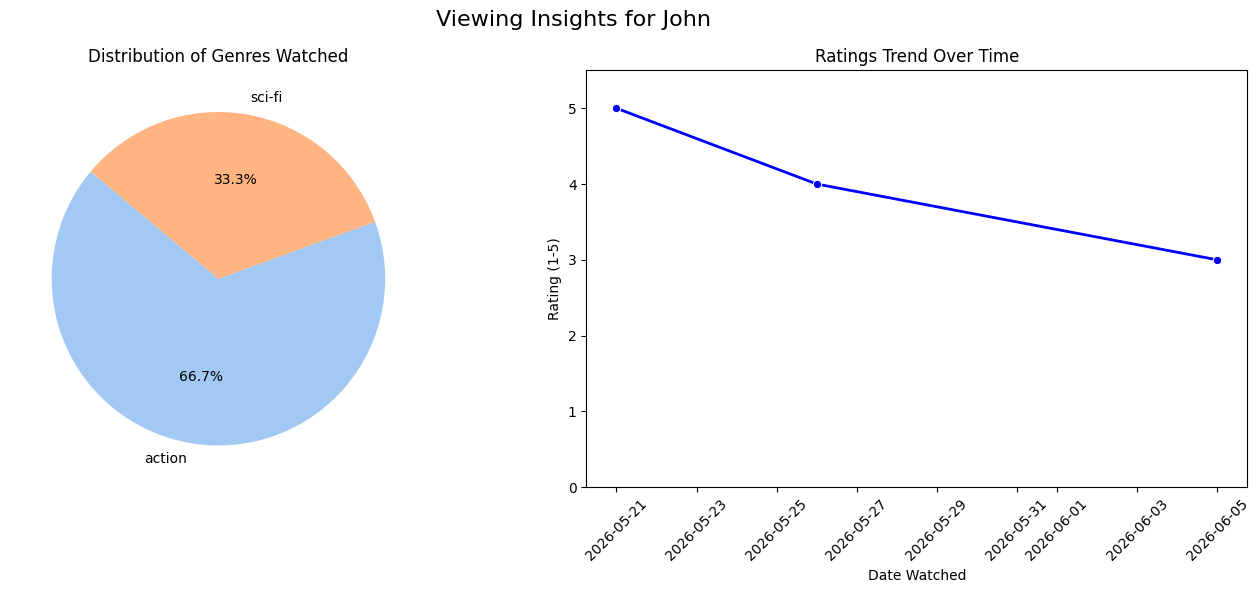

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.cluster.vq import kmeans, vq
from datetime import datetime, timedelta

# ==========================================
# 1. Simulate User Data & OOP Structure
# ==========================================

class User:
    """Encapsulates user data and viewing history."""
    def __init__(self, user_id, name, age, preferences, watch_history):
        self.user_id = user_id
        self.name = name
        self.age = age
        self.preferences = preferences  # List of genres
        self.watch_history = watch_history  # List of dicts

    def get_watched_movies(self):
        """Returns a list of movie titles watched by the user."""
        return list(map(lambda x: x['movie'], self.watch_history))

class RecommendationEngine:
    """Handles logic for filtering, clustering, and recommending."""
    def __init__(self, users_data, movie_catalog):
        self.users = {u['user_id']: User(**u) for u in users_data}
        self.movie_catalog = pd.DataFrame(movie_catalog)
        
        # Build a global ratings matrix for SciPy operations
        self.ratings_df = self._build_ratings_matrix(users_data)

    def _build_ratings_matrix(self, users_data):
        """Helper to create a user-item rating DataFrame."""
        records = []
        for u in users_data:
            for w in u['watch_history']:
                records.append({
                    'user_id': u['user_id'],
                    'movie': w['movie'],
                    'rating': w['rating']
                })
        df = pd.DataFrame(records)
        # Pivot table: Users as rows, Movies as columns, Ratings as values
        return df.pivot(index='user_id', columns='movie', values='rating').fillna(0)

    # ==========================================
    # 2. Build the Recommendation Engine
    # ==========================================

    def recommend_by_preference(self, user_id):
        """Filters movies based on user's preferred genres."""
        user = self.users[user_id]
        watched = user.get_watched_movies()
        
        # Filter movies: matching preferences AND not already watched
        # Using lambda and filter concepts via Pandas boolean indexing
        mask = self.movie_catalog['genre'].apply(lambda g: g in user.preferences)
        unwatched_mask = ~self.movie_catalog['title'].isin(watched)
        
        recommendations = self.movie_catalog[mask & unwatched_mask]
        
        print(f"\n--- Basic Recommendations for {user.name} ---")
        if not recommendations.empty:
            for _, row in recommendations.iterrows():
                print(f"Since you like {row['genre']}, you might enjoy '{row['title']}'.")
        else:
            print("No new movies found matching your preferences.")

    def find_similar_users_pearson(self, target_user_id):
        """Uses SciPy Pearson Correlation to find similar users based on ratings."""
        print(f"\n--- SciPy Pearson Correlation for User {target_user_id} ---")
        target_ratings = self.ratings_df.loc[target_user_id].values
        
        similarities = []
        for other_user_id in self.ratings_df.index:
            if target_user_id == other_user_id:
                continue
            
            other_ratings = self.ratings_df.loc[other_user_id].values
            
            # SciPy Pearson Correlation requires arrays of the same length
            # If standard deviation is 0 (e.g., all 0 ratings), pearsonr returns NaN
            if np.std(target_ratings) > 0 and np.std(other_ratings) > 0:
                corr, _ = pearsonr(target_ratings, other_ratings)
                similarities.append((other_user_id, corr))
                
        # Sort by highest correlation
        similarities.sort(key=lambda x: x[1], reverse=True)
        for uid, score in similarities:
            print(f"Similarity with User {uid} ({self.users[uid].name}): {score:.2f}")

    def cluster_users_kmeans(self):
        """Uses SciPy K-Means to cluster users based on their rating behavior."""
        print("\n--- SciPy K-Means Clustering ---")
        # Convert DataFrame to a NumPy array for SciPy
        data = self.ratings_df.values.astype(float)
        
        # Whitening the data is recommended for SciPy K-means
        from scipy.cluster.vq import whiten
        whitened_data = whiten(data)
        
        # Perform K-means with 2 clusters
        centroids, _ = kmeans(whitened_data, 2)
        
        # Assign users to clusters
        cluster_assignments, _ = vq(whitened_data, centroids)
        
        for user_id, cluster_id in zip(self.ratings_df.index, cluster_assignments):
            print(f"User {user_id} ({self.users[user_id].name}) belongs to Cluster {cluster_id}")

    # ==========================================
    # 3. Analyze and Visualize Insights
    # ==========================================

    def visualize_user_insights(self, user_id):
        """Generates visualizations for a specific user's viewing habits."""
        user = self.users[user_id]
        history_df = pd.DataFrame(user.watch_history)
        
        if history_df.empty:
            print("No viewing history to visualize.")
            return

        # Setup plot figure with 2 subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f"Viewing Insights for {user.name}", fontsize=16)

        # 1. Pie Chart of Genres
        genre_counts = history_df['genre'].value_counts()
        axes[0].pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', 
                    colors=sns.color_palette("pastel"), startangle=140)
        axes[0].set_title("Distribution of Genres Watched")

        # 2. Line Plot of Ratings Over Time
        # Ensure dates are sorted
        history_df['date_watched'] = pd.to_datetime(history_df['date_watched'])
        history_df = history_df.sort_values('date_watched')
        
        sns.lineplot(ax=axes[1], x='date_watched', y='rating', data=history_df, 
                     marker='o', color='b', linewidth=2)
        axes[1].set_title("Ratings Trend Over Time")
        axes[1].set_xlabel("Date Watched")
        axes[1].set_ylabel("Rating (1-5)")
        axes[1].set_ylim(0, 5.5)
        
        # Rotate dates for better readability
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()

# ==========================================
# Execution and Simulation
# ==========================================

if __name__ == "__main__":
    # Mock Movie Dataset
    movie_catalog = [
        {"title": "Inception", "genre": "sci-fi", "director": "Nolan"},
        {"title": "Interstellar", "genre": "sci-fi", "director": "Nolan"},
        {"title": "The Dark Knight", "genre": "action", "director": "Nolan"},
        {"title": "Die Hard", "genre": "action", "director": "McTiernan"},
        {"title": "The Godfather", "genre": "drama", "director": "Coppola"},
        {"title": "Parasite", "genre": "thriller", "director": "Bong"},
    ]

    # Mock User Data (with simulated dates)
    today = datetime.today()
    users_data = [
        {
            "user_id": 1,
            "name": "John",
            "age": 25,
            "preferences": ["action", "sci-fi"],
            "watch_history": [
                {"movie": "Inception", "genre": "sci-fi", "rating": 5, "date_watched": (today - timedelta(days=20)).strftime('%Y-%m-%d')},
                {"movie": "The Dark Knight", "genre": "action", "rating": 4, "date_watched": (today - timedelta(days=15)).strftime('%Y-%m-%d')},
                {"movie": "Die Hard", "genre": "action", "rating": 3, "date_watched": (today - timedelta(days=5)).strftime('%Y-%m-%d')}
            ]
        },
        {
            "user_id": 2,
            "name": "Sarah",
            "age": 30,
            "preferences": ["drama", "thriller"],
            "watch_history": [
                {"movie": "The Godfather", "genre": "drama", "rating": 5, "date_watched": (today - timedelta(days=10)).strftime('%Y-%m-%d')},
                {"movie": "Parasite", "genre": "thriller", "rating": 5, "date_watched": (today - timedelta(days=2)).strftime('%Y-%m-%d')}
            ]
        },
        {
            "user_id": 3,
            "name": "Mike",
            "age": 22,
            "preferences": ["sci-fi"],
            "watch_history": [
                {"movie": "Inception", "genre": "sci-fi", "rating": 4, "date_watched": (today - timedelta(days=25)).strftime('%Y-%m-%d')},
                {"movie": "Interstellar", "genre": "sci-fi", "rating": 5, "date_watched": (today - timedelta(days=1)).strftime('%Y-%m-%d')}
            ]
        }
    ]

    # Initialize Engine
    engine = RecommendationEngine(users_data, movie_catalog)

    # 1. Content-Based Filtering (Basic Generative Prompt Simulation)
    engine.recommend_by_preference(user_id=1)

    # 2. Collaborative Filtering (SciPy Pearson Correlation)
    # We see how similar John (1) is to Sarah (2) and Mike (3)
    engine.find_similar_users_pearson(target_user_id=1)

    # 3. User Clustering (SciPy K-Means)
    engine.cluster_users_kmeans()

    # 4. Visualizations (Matplotlib / Seaborn)
    engine.visualize_user_insights(user_id=1)